Loading data from: ../data/Universities_2_3_5_6_8_Cleaned.csv...
Verifying financial data types...
Generating charts. Copies will be saved to '../eda_charts'...


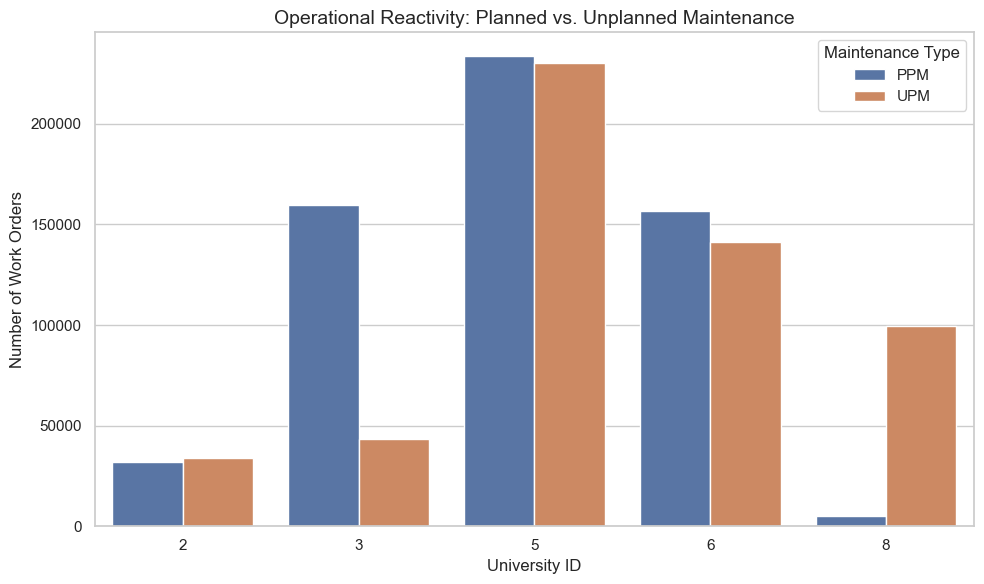

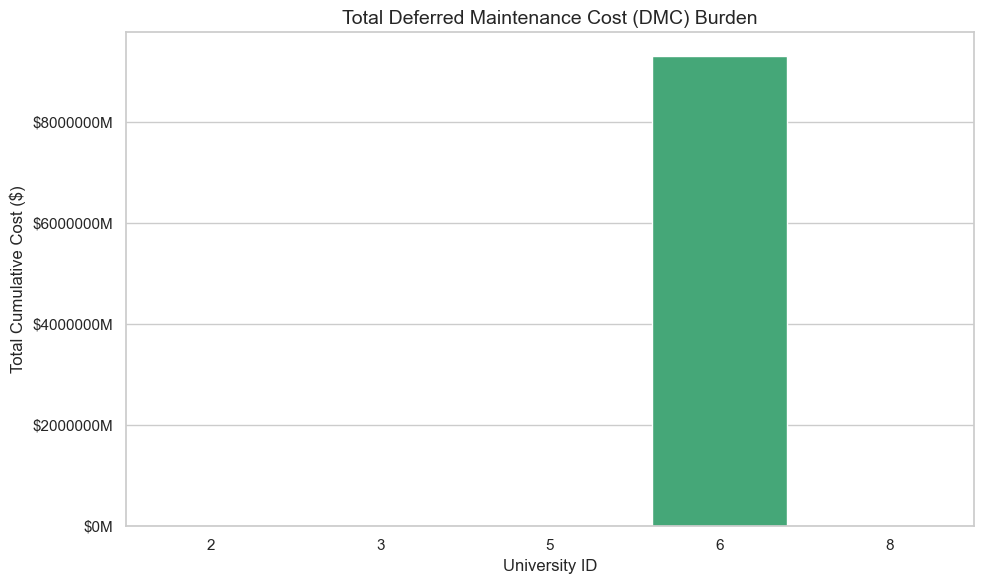

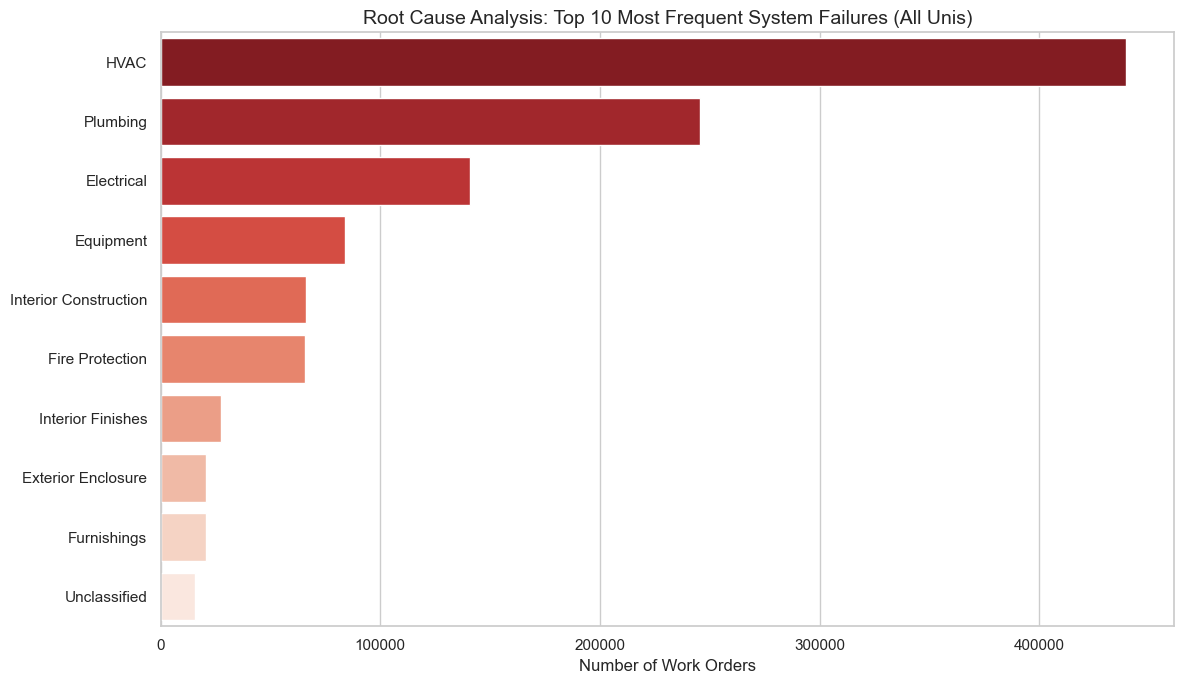

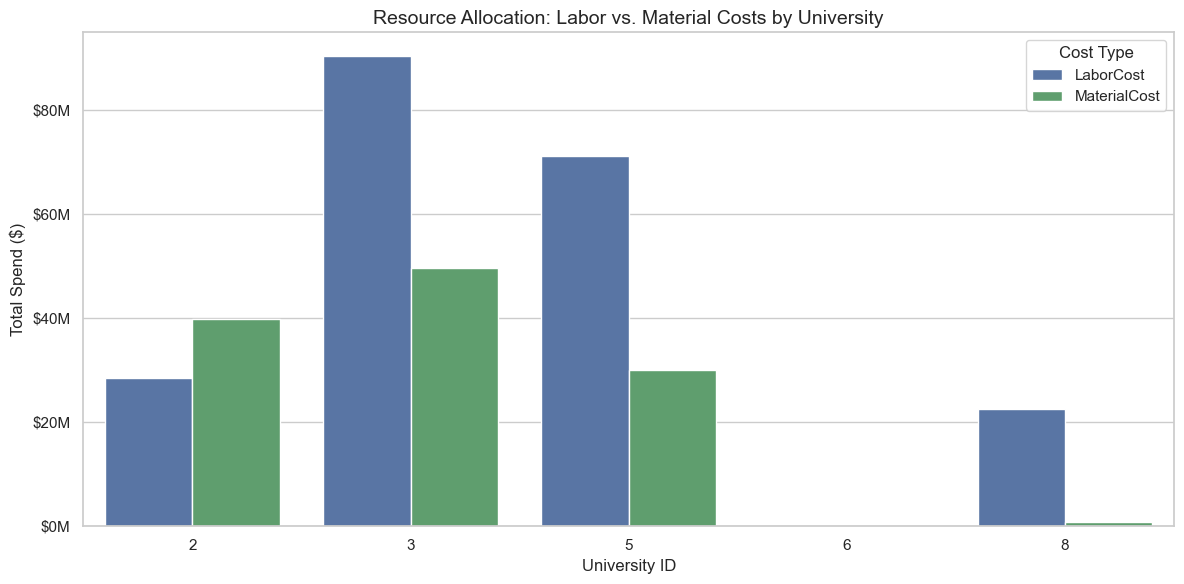

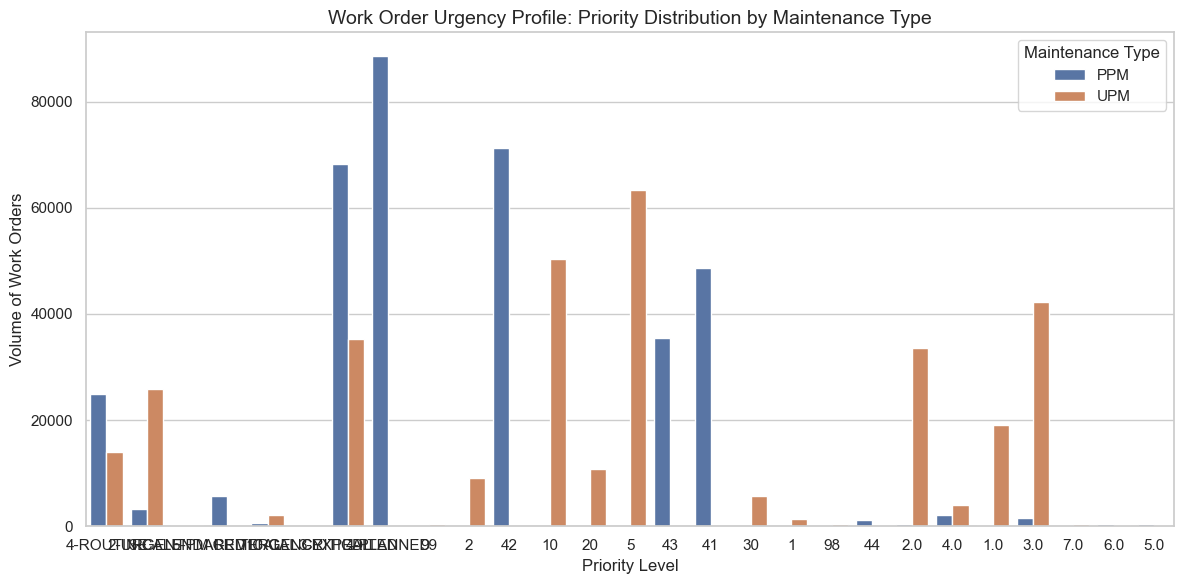


Success! EDA complete.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup paths relative to the 'notebooks' folder
# Stepping back one level to access the data folder
input_file = "../data/Universities_2_3_5_6_8_Cleaned.csv"
charts_folder = "../eda_charts"

# Create the output directory at the root level if it doesn't exist
if not os.path.exists(charts_folder):
    os.makedirs(charts_folder)

print(f"Loading data from: {input_file}...")
df = pd.read_csv(input_file, low_memory=False)

# Ensure financial columns are strictly numeric
print("Verifying financial data types...")
cost_cols = ['DMC (deferred maintenance cost)', 'LaborCost', 'MaterialCost', 'TotalCost']
for col in cost_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce').fillna(0)

# Set the visualization style
sns.set_theme(style="whitegrid")
print(f"Generating charts. Copies will be saved to '{charts_folder}'...")

# =========================================================
# ANALYSIS CHART 1: Operational Reactivity (PPM vs. UPM)
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='UniversityID', hue='PPM/UPM', palette=['#4C72B0', '#DD8452'])
plt.title('Operational Reactivity: Planned vs. Unplanned Maintenance', fontsize=14)
plt.ylabel('Number of Work Orders', fontsize=12)
plt.xlabel('University ID', fontsize=12)
plt.legend(title='Maintenance Type')
plt.tight_layout()
plt.savefig(os.path.join(charts_folder, '1_PPM_vs_UPM_Volume.png'), dpi=300)
plt.show() # Renders the chart directly in the notebook

# =========================================================
# ANALYSIS CHART 2: Total Financial Backlog (DMC)
# =========================================================
cost_col = 'DMC (deferred maintenance cost)'
total_costs = df.groupby('UniversityID')[cost_col].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=total_costs, x='UniversityID', y=cost_col, hue='UniversityID', palette='viridis', legend=False)
plt.title('Total Deferred Maintenance Cost (DMC) Burden', fontsize=14)
plt.ylabel('Total Cumulative Cost ($)', fontsize=12)
plt.xlabel('University ID', fontsize=12)

def millions_formatter(x, pos):
    return f'${x*1e-6:.0f}M'
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(millions_formatter))
plt.tight_layout()
plt.savefig(os.path.join(charts_folder, '2_Total_DMC_Burden.png'), dpi=300)
plt.show()

# =========================================================
# ANALYSIS CHART 3: Root Cause - Top 10 Failing Systems
# =========================================================
df_cleaned_sys = df.copy()
df_cleaned_sys['SystemDescription'] = df_cleaned_sys['SystemDescription'].fillna('Unknown System')

top_systems = df_cleaned_sys['SystemDescription'].value_counts().nlargest(10).reset_index()
top_systems.columns = ['SystemDescription', 'Count']

plt.figure(figsize=(12, 7))
sns.barplot(data=top_systems, y='SystemDescription', x='Count', hue='SystemDescription', palette='Reds_r', legend=False)
plt.title('Root Cause Analysis: Top 10 Most Frequent System Failures (All Unis)', fontsize=14)
plt.xlabel('Number of Work Orders', fontsize=12)
plt.ylabel('', fontsize=12) 
plt.tight_layout()
plt.savefig(os.path.join(charts_folder, '3_Top_10_System_Failures.png'), dpi=300)
plt.show()

# =========================================================
# ANALYSIS CHART 4: Spend Breakdown (Labor vs. Material)
# =========================================================
spend_breakdown = df.groupby('UniversityID')[['LaborCost', 'MaterialCost']].sum().reset_index()
spend_melted = spend_breakdown.melt(id_vars='UniversityID', value_vars=['LaborCost', 'MaterialCost'], 
                                    var_name='Cost Type', value_name='Amount')

plt.figure(figsize=(12, 6))
sns.barplot(data=spend_melted, x='UniversityID', y='Amount', hue='Cost Type', palette=['#4C72B0', '#55A868'])
plt.title('Resource Allocation: Labor vs. Material Costs by University', fontsize=14)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.xlabel('University ID', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(millions_formatter))
plt.tight_layout()
plt.savefig(os.path.join(charts_folder, '4_Labor_vs_Material_Spend.png'), dpi=300)
plt.show()

# =========================================================
# ANALYSIS CHART 5: Urgency vs. Maintenance Type
# =========================================================
if 'WOPriority' in df.columns:
    plt.figure(figsize=(12, 6))
    df_priority = df.dropna(subset=['WOPriority'])
    sns.countplot(data=df_priority, x='WOPriority', hue='PPM/UPM', palette=['#4C72B0', '#DD8452'])
    plt.title('Work Order Urgency Profile: Priority Distribution by Maintenance Type', fontsize=14)
    plt.xlabel('Priority Level', fontsize=12)
    plt.ylabel('Volume of Work Orders', fontsize=12)
    plt.legend(title='Maintenance Type')
    plt.tight_layout()
    plt.savefig(os.path.join(charts_folder, '5_Priority_Distribution.png'), dpi=300)
    plt.show()

print("\nSuccess! EDA complete.")